# Melbourne Traffic Congestion Forecasting Assistant

Authored by: Qizhe Yew  
Level: Intermediate  
Pre-requisite skills: Python

## Scenario

In a busy city with lots of traffic, commuters and transport planners need timely insight into when and where congestion is likely to occur. This use case combines Melbourne transport activity counts and microclimate data to predict whether a selected sensor location will experience Low, Medium, or High congestion. The system also uses an LLM and RAG layer to explain predictions to users and provide practical travel or planning recommendations.

## What This Use Case Teaches You

By completing this use case, you will learn how to:
- Preprocess large traffic and environmental datasets, create per-location congestion labels, using API to access datasets
- Engineer time and location-based features
- Train and compare classification models, fine-tune XGBoost, interpret model outputs
- Use LLM/RAG techniques to turn predictions into understandable smart-city insights.


# Melbourne Traffic Congestion Prediction Pipeline

This notebook follows the project pipeline below:

1. **Preprocessing** - load the transport and microclimate data, clean timestamps, merge datasets, create per-location congestion labels, and prepare model features.
2. **Model Training** - split the data by time, scale features, and train baseline, Random Forest, and XGBoost classifiers.
3. **Fine Tuning** - tune the XGBoost model and evaluate the final model on the untouched test period.
4. **LLM Explanation** - connect the trained model output combined with live/forecast Open-Meteo weather value to Gemini/Groq so predictions can be explained in plain English.
5. **Prompt Engineering** - structure the assistant instructions and prediction context passed into the LLM.
6. **RAG** - retrieve relevant traffic knowledge and compare normal LLM output with RAG-enhanced output.
7. **User Interface** - simple user interface displaying the core functions of the congestion forecasting assistant made using Streamlit.


## 1. Preprocessing

### Dataset Analysis Before Preprocessing

Before preprocessing, the raw datasets are inspected to understand what needs cleaning and preparation. The Transport Activity Count ZIP files provide 5-minute sensor records with location names, directions, vehicle classes, timestamps, coordinates, and counts. The microclimate dataset provides weather and environmental readings which are averaged by hour as city-wide weather and can be joined by hour. This stage checks the available columns, date range, vehicle classes, missing values, duplicate rows, and timestamp behaviour for the preprocessing steps.

### Preprocessing Summary

This section then loads the raw Transport Activity Count and microclimate data, handles Melbourne-local timestamps, filters to vehicle classes, aggregates 5-minute records into hourly traffic volumes, merges weather context, creates per-location Low/Medium/High congestion labels, and prepares the clean dataset to be used by the model.


In [1]:
# =============================================================================
# MELBOURNE TRAFFIC CONGESTION PREDICTION
# Data loading + preprocessing, updated for the refreshed Transport Activity Count files
# =============================================================================

import io
import os
import re
import time
import zipfile
from pathlib import Path
from datetime import datetime, timedelta

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier


CLASS_NAMES = ["Low", "Medium", "High"]

# Prints the same evaluation metrics for each model so results can be compared consistently.
# This keeps accuracy, balanced accuracy, precision, recall, and F1 in one place.
def print_model_metrics(title, y_true, y_pred):
    """Print consistent model evaluation metrics."""
    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    print("Summary metrics:")
    print(f"  Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Balanced accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"  Macro precision:    {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Macro recall:       {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Macro F1:           {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  Weighted F1:        {f1_score(y_true, y_pred, average='weighted'):.4f}")

# =============================================================================
# CONFIGURATION
# =============================================================================

TRANSPORT_ZIP_URLS = {
    2024: "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2024.zip",
    2025: "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip",
}
DEPENDENCIES_DIR = Path("dependencies")
TRANSPORT_CACHE_DIR = DEPENDENCIES_DIR / "transport_data"
TRANSPORT_LEGACY_CACHE_DIR = Path("transport_data")
MICROCLIMATE_CSV_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/microclimate-sensors-data/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"
MICROCLIMATE_CACHE_PATH = DEPENDENCIES_DIR / "microclimate-sensors-data.csv"
MICROCLIMATE_LEGACY_CACHE_PATH = Path("microclimate-sensors-data.csv")
OUTPUT_DATASET = str(DEPENDENCIES_DIR / "final_dataset_melbourne.csv")
WEATHER_FEATURES = ["AirTemperature", "AverageWindSpeed", "RelativeHumidity", "PM25", "Noise"]

TRAIN_START = "2024-01-01"
TRAIN_END = "2026-01-01"

VEHICLE_TYPES = {
    "van", "car", "motorbike", "bus", "truck", "rigid",
    "minibus", "taxi", "emergency_van", "emergency_car", "fire_engine"
}

# Known non-vehicle or unreliable counters from the original implementation.
EXCLUDE_SENSORS = {45473, 45474, 45475, 45039, 45040, 45216, 45217, 45218, 57969, 58095}
RANDOM_STATE = 42

DEPENDENCIES_DIR.mkdir(parents=True, exist_ok=True)
TRANSPORT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# LOAD TRANSPORT ACTIVITY COUNT ZIP FILES
# =============================================================================

def is_valid_zip_file(path):
    """Return True only when the local cache is a readable ZIP archive."""
    try:
        return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)
    except OSError:
        return False


def find_local_transport_zip(year, preferred_path=None):
    """Find a valid local transport ZIP in dependencies first, then legacy locations."""
    candidates = []
    if preferred_path is not None:
        candidates.append(Path(preferred_path))
    candidates.extend([
        TRANSPORT_CACHE_DIR / f"TransportActivityCount_{year}.zip",
        TRANSPORT_LEGACY_CACHE_DIR / f"TransportActivityCount_{year}.zip",
    ])

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        if is_valid_zip_file(path):
            return path
    return None


# Downloads each yearly Transport Activity Count ZIP from the API.
# If the API fails, it falls back to a valid local file so the notebook can still run.
def download_transport_zip(year, url, cache_dir=TRANSPORT_CACHE_DIR):
    """Download transport ZIPs from the API first, falling back to a valid local copy if needed."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    zip_path = cache_dir / f"TransportActivityCount_{year}.zip"
    temp_path = cache_dir / f"TransportActivityCount_{year}.zip.tmp"

    print(f"Downloading TransportActivityCount_{year}.zip from API")
    try:
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=120)
        response.raise_for_status()

        content_type = response.headers.get("Content-Type", "")
        if response.content[:2] != b"PK":
            preview = response.text[:300].replace("\n", " ")
            raise ValueError(
                f"Response was not a ZIP. Content-Type: {content_type}. Preview: {preview}"
            )

        temp_path.write_bytes(response.content)
        if not is_valid_zip_file(temp_path):
            raise zipfile.BadZipFile(f"Downloaded TransportActivityCount_{year}.zip is incomplete or invalid.")

        temp_path.replace(zip_path)
        print(f"Saved API transport data to {zip_path}")
        return zip_path

    except Exception as exc:
        if temp_path.exists():
            try:
                temp_path.unlink()
            except OSError:
                pass

        fallback = find_local_transport_zip(year)
        if fallback is not None:
            print(f"Transport API failed ({exc}). Falling back to local file: {fallback}")
            return fallback

        raise RuntimeError(
            f"Could not download TransportActivityCount_{year}.zip and no valid local fallback was found."
        ) from exc



# Parses transport timestamps as Melbourne local time to avoid shifting traffic patterns.
# This is important because treating these values as UTC can move peak hours into the wrong time of day.
def parse_transport_time_series(series):
    """
    Parse TransportActivityCount timestamps as Melbourne local clock time.
    The CSV values include a trailing Z, but using it as UTC shifts the daily
    traffic pattern into midnight/morning hours.
    """
    text = (
        series.astype(str).str.strip()
        .str.replace(r"Z$", "", regex=True)
        .str.replace(r"[+-]\d{2}:?\d{2}$", "", regex=True)
    )
    parsed = pd.to_datetime(text, errors="coerce")
    return parsed.dt.tz_localize(
        "Australia/Melbourne",
        ambiguous=False,
        nonexistent="shift_forward",
    )

# Parses general Melbourne timestamps and safely handles timezone-aware or timezone-naive inputs.
# This is reused for saved datasets and microclimate timestamps.
def parse_melbourne_time_series(series):
    """Parse Melbourne timestamps safely across daylight-saving changes."""
    text = series.astype(str).str.strip()
    has_offset = text.str.contains(r"(Z|[+-]\d{2}:?\d{2})$", regex=True, na=False).mean() > 0.5
    if has_offset:
        return pd.to_datetime(series, errors="coerce", utc=True).dt.tz_convert("Australia/Melbourne")

    parsed = pd.to_datetime(series, errors="coerce")
    if getattr(parsed.dt, "tz", None) is None:
        return parsed.dt.tz_localize(
            "Australia/Melbourne",
            ambiguous=False,
            nonexistent="shift_forward",
        )
    return parsed.dt.tz_convert("Australia/Melbourne")

# Loads raw transport activity records across the configured years and filters them to the training date range.
# The output is still raw sensor-level data, before hourly aggregation and congestion labelling.
def load_transport_activity_counts(start_date=TRAIN_START, end_date=TRAIN_END):
    """Load the historical ZIP files used in the group notebook and filter to the requested date range."""
    start_ts = pd.Timestamp(start_date, tz="Australia/Melbourne")
    end_ts = pd.Timestamp(end_date, tz="Australia/Melbourne")

    frames = []
    for year, url in sorted(TRANSPORT_ZIP_URLS.items()):
        year_start = pd.Timestamp(f"{year}-01-01", tz="Australia/Melbourne")
        year_end = pd.Timestamp(f"{year + 1}-01-01", tz="Australia/Melbourne")
        if year_start >= end_ts or year_end <= start_ts:
            continue

        zip_path = download_transport_zip(year, url)
        with zipfile.ZipFile(zip_path) as archive:
            csv_names = sorted(name for name in archive.namelist() if name.lower().endswith(".csv"))
            print(f"{zip_path.name}: {len(csv_names)} CSV files")
            for name in csv_names:
                with archive.open(name) as f:
                    part = pd.read_csv(f)
                part["source_file"] = name
                frames.append(part)

    if not frames:
        raise ValueError("No transport CSV files were loaded. Check TRANSPORT_ZIP_URLS and date range.")

    raw = pd.concat(frames, ignore_index=True)
    raw = standardise_transport_columns(raw)
    # TransportActivityCount timestamps behave as Melbourne local clock time.
    # Treating the trailing Z as UTC shifts the traffic pattern by 10-11 hours.
    raw["from"] = parse_transport_time_series(raw["from"])
    raw["to"] = parse_transport_time_series(raw["to"])
    raw = raw.dropna(subset=["from", "to", "count"])
    raw = raw[(raw["from"] >= start_ts) & (raw["from"] < end_ts)].copy()
    raw = raw[raw["to"] >= raw["from"]].copy()

    print(f"Raw transport rows after date filtering: {raw.shape}")
    return raw


# Standardises transport column names and types so later preprocessing can rely on consistent fields.
# It keeps the original countlineName-based location identity used by the current dataset.
def standardise_transport_columns(df):
    """Clean current Transport Activity Count fields without renaming the ID column."""
    df = df.copy()
    df.columns = [str(col).strip().replace("\ufeff", "") for col in df.columns]

    rename_map = {
        "countlineLat": "CountLocationLat",
        "countlineLong": "CountLocationLong",
        "countlineLon": "CountLocationLong",
    }
    df = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})

    if "countlineDirection" not in df.columns:
        df["countlineDirection"] = "Unknown"
    if "countlineName" not in df.columns:
        df["countlineName"] = "Unknown Location"
    if "CountLocationLat" not in df.columns:
        df["CountLocationLat"] = np.nan
    if "CountLocationLong" not in df.columns:
        df["CountLocationLong"] = np.nan

    required = ["from", "to", "class", "count", "countlineName", "countlineDirection"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required transport columns: {missing}")

    df["count"] = pd.to_numeric(df["count"], errors="coerce")
    if "countlineId" in df.columns:
        df["countlineId"] = pd.to_numeric(df["countlineId"], errors="coerce")
    df["class"] = df["class"].astype(str).str.strip().str.lower().apply(
        lambda value: re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    )
    df["countlineDirection"] = df["countlineDirection"].fillna("Unknown").astype(str).str.strip()
    df = df.dropna(subset=["count", "countlineName"])
    if "countlineId" in df.columns:
        df["countlineId"] = df["countlineId"].astype("Int64")
    return df


# =============================================================================
# LOAD AND PREPROCESS MICROCLIMATE SENSOR DATA
# =============================================================================

def is_readable_csv_file(path):
    """Return True when a CSV cache exists and pandas can read its header."""
    try:
        return path.exists() and path.stat().st_size > 0 and not pd.read_csv(path, nrows=5).empty
    except Exception:
        return False


def find_local_microclimate_csv(preferred_path=None):
    """Find a readable microclimate CSV in dependencies first, then legacy root location."""
    candidates = []
    if preferred_path is not None:
        candidates.append(Path(preferred_path))
    candidates.extend([MICROCLIMATE_CACHE_PATH, MICROCLIMATE_LEGACY_CACHE_PATH])

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        if is_readable_csv_file(path):
            return path
    return None


# Loads Melbourne microclimate readings and aggregates them into hourly city-wide weather values.
# These hourly values are later merged with traffic records by timestamp.
def load_microclimate_data(url=MICROCLIMATE_CSV_URL, cache_path=MICROCLIMATE_CACHE_PATH):
    """Load microclimate data from the API first, falling back to a valid local copy if needed."""
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = cache_path.with_suffix(cache_path.suffix + ".tmp")

    print("Downloading microclimate sensor CSV export from API")
    try:
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=120)
        response.raise_for_status()
        temp_path.write_bytes(response.content)

        if not is_readable_csv_file(temp_path):
            preview = response.text[:300].replace("\n", " ")
            raise ValueError(f"Downloaded microclimate response was not a readable CSV. Preview: {preview}")

        temp_path.replace(cache_path)
        print(f"Saved API microclimate data to {cache_path}")
        weather = pd.read_csv(cache_path)

    except Exception as exc:
        if temp_path.exists():
            try:
                temp_path.unlink()
            except OSError:
                pass

        fallback = find_local_microclimate_csv()
        if fallback is None:
            raise RuntimeError(
                "Could not download microclimate data and no valid local fallback was found."
            ) from exc

        print(f"Microclimate API failed ({exc}). Falling back to local file: {fallback}")
        weather = pd.read_csv(fallback)

    weather.columns = [str(col).strip().replace("\ufeff", "") for col in weather.columns]
    compact_names = {"".join(ch for ch in col.lower() if ch.isalnum()): col for col in weather.columns}

    time_col = None
    for key in ["time", "receivedat", "datetime", "timestamp"]:
        if key in compact_names:
            time_col = compact_names[key]
            break
    if time_col is None:
        raise ValueError(f"Could not find a timestamp column in microclimate data. Columns: {weather.columns.tolist()}")

    rename_map = {}
    for compact, original in compact_names.items():
        if "airtemperature" in compact or compact == "temperature":
            rename_map[original] = "AirTemperature"
        elif "averagewindspeed" in compact or compact == "windspeed":
            rename_map[original] = "AverageWindSpeed"
        elif "relativehumidity" in compact or compact == "humidity":
            rename_map[original] = "RelativeHumidity"
        elif "pm25" in compact or "pm2" in compact:
            rename_map[original] = "PM25"
        elif "pm10" in compact:
            rename_map[original] = "PM10"
        elif "noise" in compact:
            rename_map[original] = "Noise"
    weather = weather.rename(columns=rename_map)

    weather["time"] = parse_melbourne_time_series(weather[time_col]).dt.floor("h", ambiguous=False, nonexistent="shift_forward")
    available = [col for col in ["time"] + WEATHER_FEATURES + ["PM10"] if col in weather.columns]
    weather = weather[available].copy()
    for col in [c for c in available if c != "time"]:
        weather[col] = pd.to_numeric(weather[col], errors="coerce")

    weather_hourly = weather.groupby("time", as_index=False).median(numeric_only=True)
    for col in WEATHER_FEATURES:
        if col not in weather_hourly.columns:
            weather_hourly[col] = np.nan
    weather_hourly[WEATHER_FEATURES] = weather_hourly[WEATHER_FEATURES].ffill().bfill()

    print(f"Microclimate hourly data: {weather_hourly.shape}")
    return weather_hourly[["time"] + WEATHER_FEATURES]


In [2]:
# =============================================================================
# LOAD DATASETS FOR ANALYSIS
# =============================================================================

raw_transport_df = load_transport_activity_counts()
try:
    weather_hourly = load_microclimate_data()
except Exception as e:
    print(f"Microclimate loading failed: {e}")
    print("Continuing with neutral zero-valued microclimate features.")
    fallback_times = raw_transport_df["from"].dt.floor(
        "h", ambiguous=False, nonexistent="shift_forward"
    )


Saved API transport data to dependencies/transport_data/TransportActivityCount_2024.zip
TransportActivityCount_2024.zip: 4 CSV files
Saved API transport data to dependencies/transport_data/TransportActivityCount_2025.zip
TransportActivityCount_2025.zip: 4 CSV files
Raw transport rows after date filtering: (10765361, 12)
Saved API microclimate data to dependencies/microclimate-sensors-data.csv


/var/folders/8k/qhvz9ryn3qv9kngpz8mznwwm0000gn/T/ipykernel_6992/576402893.py:185: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_offset = text.str.contains(r"(Z|[+-]\d{2}:?\d{2})$", regex=True, na=False).mean() > 0.5


Microclimate hourly data: (34045, 7)


In [3]:
# =============================================================================
# DATASET ANALYSIS BEFORE PREPROCESSING
# =============================================================================

analysis_summary = pd.DataFrame({
    "dataset": ["transport", "microclimate"],
    "rows": [len(raw_transport_df), len(weather_hourly)],
    "columns": [raw_transport_df.shape[1], weather_hourly.shape[1]],
    "start_time": [raw_transport_df["from"].min(), weather_hourly["time"].min()],
    "end_time": [raw_transport_df["from"].max(), weather_hourly["time"].max()],
})
display(analysis_summary)

print("=== TRANSPORT ACTIVITY COUNT DATA ===")
print("Transport columns:", raw_transport_df.columns.tolist())
print("Transport classes:", sorted(raw_transport_df["class"].dropna().unique())[:20])
print("Duplicate transport rows:", raw_transport_df.duplicated().sum())
print("Top missing-value columns:")
print(raw_transport_df.isna().sum().sort_values(ascending=False).head())

print("=== MICROCLIMATE DATA ===")
print("Microclimate columns:", weather_hourly.columns.tolist())
print("Duplicate microclimate rows:", weather_hourly.duplicated().sum())
print("Top missing-value columns:")
print(weather_hourly.isna().sum().sort_values(ascending=False).head())

,dataset,rows,columns,start_time,end_time
0,transport,10765361,12,2024-01-01 00:00:00+11:00,2025-12-31 23:55:00+11:00
1,microclimate,34045,6,2022-05-31 10:00:00+10:00,2026-05-07 15:00:00+10:00


=== TRANSPORT ACTIVITY COUNT DATA ===
Transport columns: ['countLocationId', 'countlineName', 'countlineDirection', 'CountLocationLat', 'CountLocationLong', 'from', 'to', 'class', 'count', 'year', 'quarter', 'source_file']
Transport classes: ['bus', 'car', 'cyclist', 'emergency_car', 'emergency_van', 'escooter', 'fire_engine', 'minibus', 'motorbike', 'pedestrian', 'rigid', 'taxi', 'truck', 'van']
Duplicate transport rows: 0
Top missing-value columns:
countLocationId       0
countlineName         0
countlineDirection    0
CountLocationLat      0
CountLocationLong     0
dtype: int64
=== MICROCLIMATE DATA ===
Microclimate columns: ['time', 'AirTemperature', 'AverageWindSpeed', 'RelativeHumidity', 'PM25', 'Noise']
Duplicate microclimate rows: 0
Top missing-value columns:
time                0
AirTemperature      0
AverageWindSpeed    0
RelativeHumidity    0
PM25                0
dtype: int64


Merged transport + microclimate dataset: (291512, 17)

Processed hourly dataset: (291512, 20)
Unique locations: 78
Per-location congestion thresholds created:
             countlineName  loc_low_threshold  loc_high_threshold
count                   78          78.000000           78.000000
unique                  78                NaN                 NaN
top     DrumondSt-Crossing                NaN                 NaN
freq                     1                NaN                 NaN
mean                   NaN          87.596154          124.875000
std                    NaN         165.686707          228.908902
min                    NaN           1.000000            1.000000
25%                    NaN           1.000000            2.000000
50%                    NaN           3.000000            6.375000
75%                    NaN          78.500000          124.187500
max                    NaN         753.000000          950.250000
Top traffic hours sanity check:
hour
17    166772

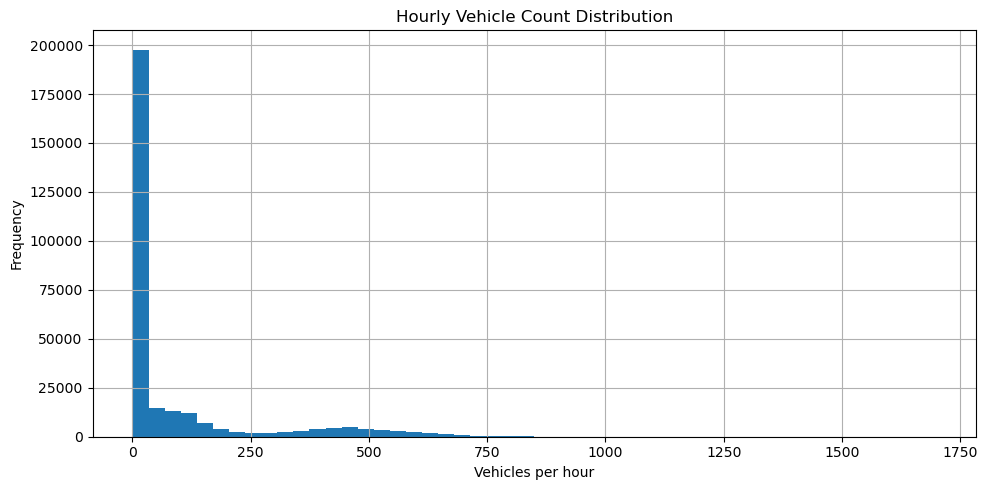

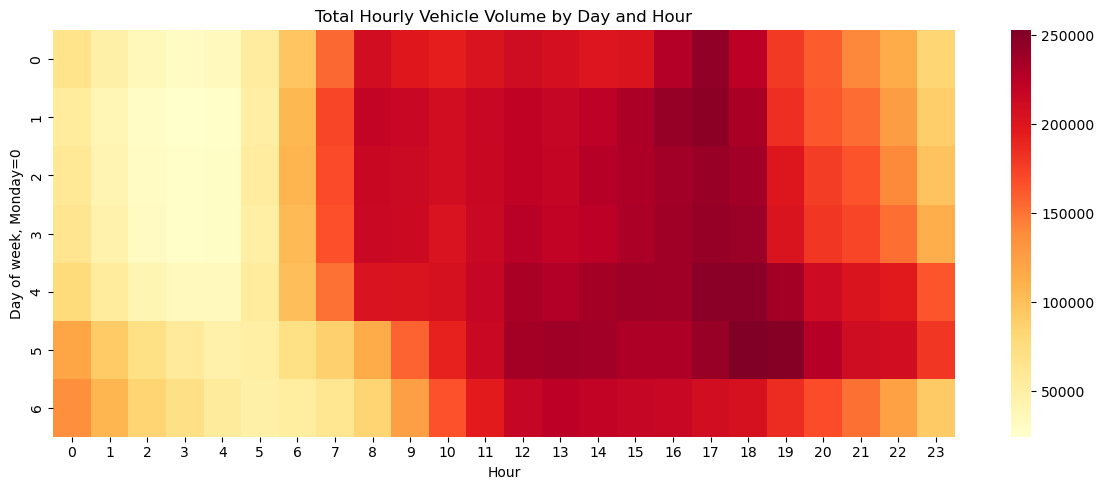

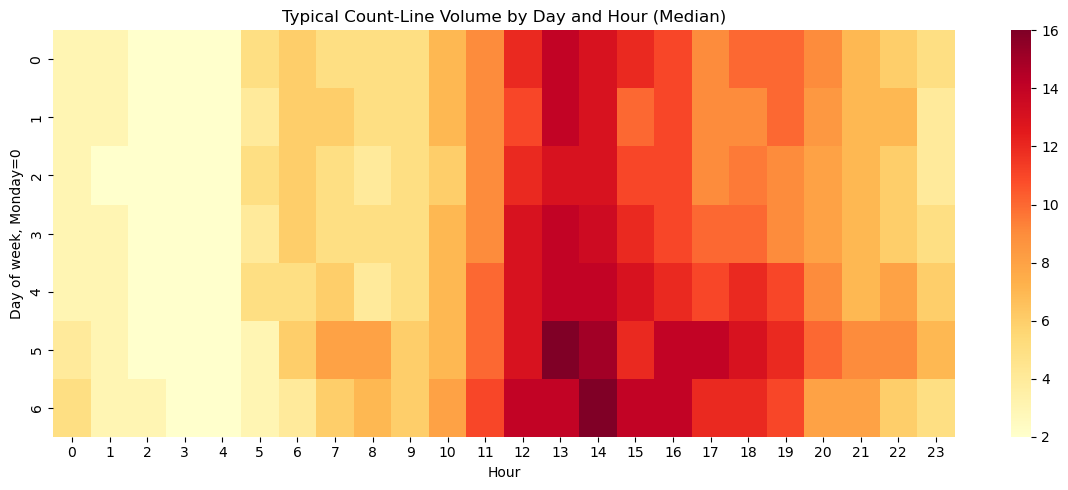

In [4]:
# =============================================================================
# PREPROCESSING
# =============================================================================

transport_df = raw_transport_df.drop_duplicates().copy()
transport_df = transport_df[transport_df["class"].isin(VEHICLE_TYPES)].copy()
transport_df["duration_minutes"] = (transport_df["to"] - transport_df["from"]).dt.total_seconds() / 60
transport_df = transport_df[transport_df["duration_minutes"] > 0].copy()

# Convert 5-minute records to hourly Melbourne-time traffic volumes.
transport_df["time"] = transport_df["from"].dt.floor("h", ambiguous=False, nonexistent="shift_forward")
transport_df = (
    transport_df
    .groupby(["time", "countlineName", "countlineDirection"], as_index=False)
    .agg(
        count=("count", "sum"),
        CountLocationLat=("CountLocationLat", "first"),
        CountLocationLong=("CountLocationLong", "first"),
    )
)

transport_df["hour"] = transport_df["time"].dt.hour
transport_df["day_of_week"] = transport_df["time"].dt.dayofweek
transport_df["month"] = transport_df["time"].dt.month
transport_df["is_weekend"] = transport_df["day_of_week"].isin([5, 6]).astype(int)
transport_df["is_morning_peak"] = transport_df["hour"].isin([7, 8, 9]).astype(int)
transport_df["is_evening_peak"] = transport_df["hour"].isin([16, 17, 18]).astype(int)


transport_df = transport_df.merge(weather_hourly, on="time", how="left")
for col in WEATHER_FEATURES:
    if col not in transport_df.columns:
        transport_df[col] = 0.0
transport_df[WEATHER_FEATURES] = transport_df[WEATHER_FEATURES].ffill().bfill().fillna(0.0)
print("Merged transport + microclimate dataset:", transport_df.shape)

# Label congestion relative to each countline's own historical traffic pattern.
# This means "High" = unusually high for that specific location, not just high city-wide.
location_thresholds = (
    transport_df
    .groupby("countlineName")["count"]
    .quantile([0.50, 0.75])
    .unstack()
    .rename(columns={0.50: "loc_low_threshold", 0.75: "loc_high_threshold"})
    .reset_index()
)

transport_df = transport_df.merge(location_thresholds, on="countlineName", how="left")

# Assigns Low, Medium, or High using thresholds calculated separately for each countlineName.
# This makes congestion relative to each sensor location instead of using one city-wide count threshold.
def congestion_label(row):
    if row["count"] < row["loc_low_threshold"]:
        return "Low"
    if row["count"] < row["loc_high_threshold"]:
        return "Medium"
    return "High"

transport_df["congestion"] = transport_df.apply(congestion_label, axis=1)

print("\nProcessed hourly dataset:", transport_df.shape)
print("Unique locations:", transport_df["countlineName"].nunique())
print("Per-location congestion thresholds created:")
print(location_thresholds.describe(include="all"))

hourly_sanity = transport_df.groupby("hour")["count"].sum().sort_values(ascending=False).head(5)
print("Top traffic hours sanity check:")
print(hourly_sanity)
print("Congestion distribution:\n", transport_df["congestion"].value_counts())

transport_df.to_csv(OUTPUT_DATASET, index=False)
print(f"\nSaved clean dataset: {OUTPUT_DATASET}")

df = transport_df.copy()
sensor_info = (
    df.groupby("countlineName", as_index=False)
    .agg(
        lat=("CountLocationLat", "first"),
        lon=("CountLocationLong", "first"),
        avg_count=("count", "mean"),
        name=("countlineName", "first"),
    )
    .dropna(subset=["lat", "lon"])
)
pd.set_option("display.max_columns", None)
df.head()

plt.figure(figsize=(10, 5))
df["count"].hist(bins=50)
plt.title("Hourly Vehicle Count Distribution")
plt.xlabel("Vehicles per hour")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

network_pivot = df.pivot_table(values="count", index="day_of_week", columns="hour", aggfunc="sum")
plt.figure(figsize=(12, 5))
sns.heatmap(network_pivot, cmap="YlOrRd")
plt.title("Total Hourly Vehicle Volume by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of week, Monday=0")
plt.tight_layout()
plt.show()

typical_pivot = df.pivot_table(values="count", index="day_of_week", columns="hour", aggfunc="median")
plt.figure(figsize=(12, 5))
sns.heatmap(typical_pivot, cmap="YlOrRd")
plt.title("Typical Count-Line Volume by Day and Hour (Median)")
plt.xlabel("Hour")
plt.ylabel("Day of week, Monday=0")
plt.tight_layout()
plt.show()

In [5]:
# =========================
# STEP 1 — FEATURE PREPARATION
# =========================

df = pd.read_csv(OUTPUT_DATASET)
# Parse saved timestamps without shifting naive Melbourne-local hours.
df["time"] = parse_melbourne_time_series(df["time"])
df = df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

for col in WEATHER_FEATURES:
    if col not in df.columns:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[WEATHER_FEATURES] = df[WEATHER_FEATURES].ffill().bfill()

# Cyclical encoding keeps midnight/23:00 and Sunday/Monday close together.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Location profile features describe each counter's normal traffic behaviour.
loc_stats = df.groupby("countlineName")["count"].agg(
    loc_mean_count="mean",
    loc_median_count="median",
    loc_std_count="std",
    loc_max_count="max",
).reset_index()
loc_stats["loc_std_count"] = loc_stats["loc_std_count"].fillna(0)
df = df.merge(loc_stats, on="countlineName", how="left")

all_locations = sorted(df["countlineName"].unique())
loc_map = {location_id: idx for idx, location_id in enumerate(all_locations)}
joblib.dump(loc_map, "loc_map.pkl")
print("loc_map saved: loc_map.pkl")
df["location_encoded"] = df["countlineName"].map(loc_map)

FEATURES = [
    "location_encoded",
    "loc_mean_count", "loc_median_count", "loc_std_count", "loc_max_count",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_morning_peak", "is_evening_peak",
    "AirTemperature", "AverageWindSpeed", "RelativeHumidity", "PM25", "Noise",
]
TARGET = "congestion"

label_map = {"Low": 0, "Medium": 1, "High": 2}
df["label"] = df[TARGET].map(label_map)

print("Features ready. Shape:", df.shape)
print("NaNs after feature prep:", df[FEATURES + ["label"]].isnull().sum().sum())
print("Selected features:", FEATURES)

/var/folders/8k/qhvz9ryn3qv9kngpz8mznwwm0000gn/T/ipykernel_6992/576402893.py:185: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_offset = text.str.contains(r"(Z|[+-]\d{2}:?\d{2})$", regex=True, na=False).mean() > 0.5


loc_map saved: loc_map.pkl
Features ready. Shape: (291512, 30)
NaNs after feature prep: 0
Selected features: ['location_encoded', 'loc_mean_count', 'loc_median_count', 'loc_std_count', 'loc_max_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'AirTemperature', 'AverageWindSpeed', 'RelativeHumidity', 'PM25', 'Noise']


In [6]:
# =========================
# DATASET CHECK
# =========================

print("Clean dataset exists:", os.path.exists(OUTPUT_DATASET))
print("Rows:", len(df))
print("Time range:", df["time"].min(), "to", df["time"].max())
print("Locations:", df["countlineName"].nunique())
print("Congestion distribution:")
print(df["congestion"].value_counts())

Clean dataset exists: True
Rows: 291512
Time range: 2024-01-01 00:00:00+11:00 to 2025-12-31 23:00:00+11:00
Locations: 78
Congestion distribution:
congestion
Low       122580
High       93558
Medium     75374
Name: count, dtype: int64


## 2. Model Training

This section performs the time-based train/validation/test split, scales numeric features using training data only, and trains the baseline Logistic Regression, Random Forest, and XGBoost classification models.


In [7]:
# =========================
# STEP 2 — TEMPORAL SPLIT + SCALING
# =========================
 
val_start  = pd.Timestamp("2025-11-01", tz="Australia/Melbourne")
test_start = pd.Timestamp("2025-12-01", tz="Australia/Melbourne")
 
# Drop any remaining NaNs before splitting
before = len(df)
df = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} NaN rows — {len(df):,} remaining")
 
train = df[df["time"] <  val_start]
val   = df[(df["time"] >= val_start) & (df["time"] < test_start)]
test  = df[df["time"] >= test_start]
 
# values converts to numpy array — avoids pandas index alignment issues
X_train, y_train = train[FEATURES].values, train["label"].values
X_val,   y_val   = val[FEATURES].values,   val["label"].values
X_test,  y_test  = test[FEATURES].values,  test["label"].values
 
# Fit scaler on train only — transform val and test separately
# Fitting on the full dataset before splitting would leak val/test
# statistics into training (a common source of inflated metrics)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
 
# Sanity checks — all must print 0
assert np.isnan(X_train).sum() == 0, "NaNs in X_train!"
assert np.isnan(X_val).sum()   == 0, "NaNs in X_val!"
assert np.isnan(X_test).sum()  == 0, "NaNs in X_test!"
 
print(f"Train: {len(y_train):,}  |  Val: {len(y_val):,}  |  Test: {len(y_test):,}")
print("\nClass distribution (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = ["Low", "Medium", "High"][int(u)]
    print(f"  {label}: {c:,}")

Dropped 0 NaN rows — 291,512 remaining
Train: 257,158  |  Val: 11,720  |  Test: 22,634

Class distribution (train):
  Low: 108,535
  Medium: 66,588
  High: 82,035


In [8]:
# =========================
# STEP 3 — BASELINE MODEL
# =========================
 
# Logistic Regression serves as the baseline — the simplest possible model.
# If a fancy model only barely beats this, it signals feature issues
# rather than model inadequacy.
# class_weight='balanced' compensates for the imbalanced class distribution.
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)
lr.fit(X_train, y_train)
 
val_preds_lr = lr.predict(X_val)
print_model_metrics("Logistic Regression — Validation", y_val, val_preds_lr)

=== Logistic Regression — Validation ===
              precision    recall  f1-score   support

         Low       0.63      0.70      0.66      4486
      Medium       0.36      0.24      0.29      2872
        High       0.58      0.65      0.61      4362

    accuracy                           0.57     11720
   macro avg       0.52      0.53      0.52     11720
weighted avg       0.55      0.57      0.55     11720

Summary metrics:
  Accuracy:           0.5660
  Balanced accuracy:  0.5280
  Macro precision:    0.5241
  Macro recall:       0.5280
  Macro F1:           0.5214
  Weighted F1:        0.5524


In [9]:
# =========================
# STEP 4 — RANDOM FOREST
# =========================
 
# Random Forest builds many decision trees on random subsets of data and features, then votes on the final prediction.
# Naturally handles nonlinear relationships and gives feature importances.
# class_weight='balanced' to handle the imbalanced class distribution.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
 
val_preds_rf = rf.predict(X_val)
print_model_metrics("Random Forest — Validation", y_val, val_preds_rf)
 
# Feature importances — useful for understanding which signals matter most
importances_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nTop features (Random Forest):")
print(importances_rf.head(8))

=== Random Forest — Validation ===
              precision    recall  f1-score   support

         Low       0.73      0.73      0.73      4486
      Medium       0.44      0.54      0.49      2872
        High       0.73      0.63      0.68      4362

    accuracy                           0.65     11720
   macro avg       0.64      0.63      0.63     11720
weighted avg       0.66      0.65      0.65     11720

Summary metrics:
  Accuracy:           0.6451
  Balanced accuracy:  0.6323
  Macro precision:    0.6352
  Macro recall:       0.6323
  Macro F1:           0.6308
  Weighted F1:        0.6502

Top features (Random Forest):
hour_sin            0.136211
hour_cos            0.134466
loc_mean_count      0.125018
Noise               0.099673
loc_median_count    0.091455
loc_std_count       0.065075
RelativeHumidity    0.053775
AirTemperature      0.049482
dtype: float64


In [10]:
# =========================
# STEP 5 — XGBOOST
# =========================
 
# XGBoost builds trees sequentially, each correcting the errors of the last.
# Usually the strongest performer on tabular data with mixed feature types.
# sample_weight with compute_sample_weight handles class imbalance for multiclass problems more precisely than scale_pos_weight (binary only).
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
 
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)
xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)
 
val_preds_xgb = xgb.predict(X_val)
print_model_metrics("XGBoost — Validation", y_val, val_preds_xgb)
 

=== XGBoost — Validation ===
              precision    recall  f1-score   support

         Low       0.74      0.71      0.72      4486
      Medium       0.44      0.56      0.49      2872
        High       0.73      0.63      0.68      4362

    accuracy                           0.64     11720
   macro avg       0.64      0.63      0.63     11720
weighted avg       0.66      0.64      0.65     11720

Summary metrics:
  Accuracy:           0.6427
  Balanced accuracy:  0.6331
  Macro precision:    0.6370
  Macro recall:       0.6331
  Macro F1:           0.6311
  Weighted F1:        0.6496


### Model Training Summary

This section prepared the train/validation/test split, scaled the selected features, and trained the baseline Logistic Regression, Random Forest, and XGBoost classifiers so their validation performance could be compared.


## 3. Fine Tuning

This section tunes the XGBoost hyperparameters using the validation period, retrains the best model on train + validation data, evaluates once on the held-out test period, and saves the final model artifacts.


In [11]:
# =========================
# STEP 6 — HYPERPARAMETER TUNING
# =========================

# RandomizedSearchCV samples random combinations from the param grid
# rather than exhaustively trying every one — much faster for large spaces.
# PredefinedSplit is used instead of standard cross-validation because
# this is time-series data — we cannot randomly shuffle and split without
# leaking future information into training.
# refit=False is intentional — we manually refit on train+val in Step 7.

split_index = np.concatenate([
    np.full(len(X_train), -1),  # -1 = always in train fold
    np.zeros(len(X_val))         #  0 = always in validation fold
])
X_tune = np.vstack([X_train, X_val])
y_tune = np.concatenate([y_train, y_val])

# Apply balanced weights consistently to both train and val portions
sw_tune = np.concatenate([
    compute_sample_weight("balanced", y_train),
    compute_sample_weight("balanced", y_val)
])

ps = PredefinedSplit(split_index)

param_grid = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
}

search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_macro",
    cv=ps,
    refit=False,  # intentional — we manually refit on train+val in Step 7
    verbose=1,
    random_state=42
)
search.fit(X_tune, y_tune, sample_weight=sw_tune)

print("Best params:", search.best_params_)
print("Best val macro F1:", search.best_score_)

Fitting 1 folds for each of 30 candidates, totalling 30 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best val macro F1: 0.6393135809884996


=== Final XGBoost — Test ===
              precision    recall  f1-score   support

         Low       0.75      0.73      0.74      9559
      Medium       0.43      0.53      0.48      5914
        High       0.63      0.54      0.58      7161

    accuracy                           0.62     22634
   macro avg       0.61      0.60      0.60     22634
weighted avg       0.63      0.62      0.62     22634

Summary metrics:
  Accuracy:           0.6183
  Balanced accuracy:  0.6002
  Macro precision:    0.6061
  Macro recall:       0.6002
  Macro F1:           0.6003
  Weighted F1:        0.6223


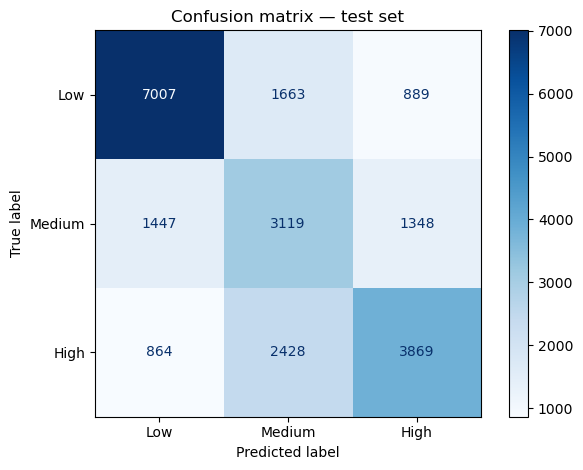

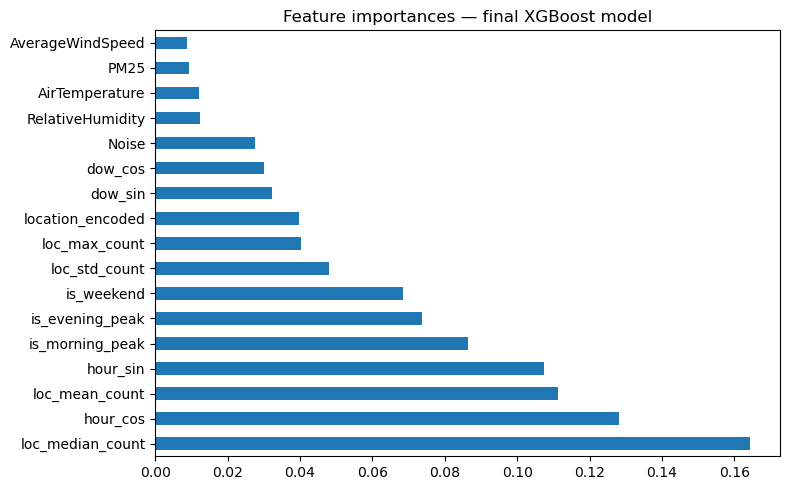


Feature importances (ranked):
loc_median_count    0.164409
hour_cos            0.128183
loc_mean_count      0.111191
hour_sin            0.107464
is_morning_peak     0.086383
is_evening_peak     0.073699
is_weekend          0.068575
loc_std_count       0.047928
loc_max_count       0.040238
location_encoded    0.039788
dow_sin             0.032265
dow_cos             0.029910
Noise               0.027672
RelativeHumidity    0.012253
AirTemperature      0.012093
PM25                0.009308
AverageWindSpeed    0.008641
dtype: float32

Model and scaler saved: congestion_model.pkl, scaler.pkl


In [12]:
# =========================
# STEP 6 — FINAL TEST EVALUATION
# =========================

# Combine train + val for final model training
X_tune = np.vstack([X_train, X_val])
y_tune = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight("balanced", y_tune)

# Final model using best hyperparameters from RandomizedSearchCV
# Using XGBoost as it showed the beat performance
best_params = search.best_params_

final_model = XGBClassifier(
    **best_params,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_tune, y_tune, sample_weight=sw_trainval)

# Evaluate on the untouched test set — runs exactly once
test_preds = final_model.predict(X_test)
print_model_metrics("Final XGBoost — Test", y_test, test_preds)

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(cmap="Blues")
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(
    final_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(8, 5))
plt.title("Feature importances — final XGBoost model")
plt.tight_layout()
plt.show()

print("\nFeature importances (ranked):")
print(importances)

# Save production artifacts for the assistant cell
joblib.dump(final_model, "congestion_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nModel and scaler saved: congestion_model.pkl, scaler.pkl")

### Fine-tuning Summary

This section tuned the XGBoost hyperparameters, retrained the final model using the best settings, evaluated it on the held-out test set, visualised performance, and saved the model artifacts for later prediction and UI use.


## 4. LLM Explanation

This section connects the saved XGBoost model, scaler, location mapping, reference dataset, Gemini client, and Groq fallback so model predictions can be turned into natural-language explanations.


In [13]:
# =========================
# STEP 8 — LLM INTEGRATION (Google Gemini & Groq)
# =========================
 
# The LLM sits on top of the XGBoost model as an interpretation layer.
# It receives the model's prediction + raw feature values and returns:
#   1. A plain English explanation of why congestion is at this level
#   2. Actionable recommendations (alternate times, route advice)
#   3. Answers to free-form questions about the prediction or data


from google import genai
from google.genai import types
from groq import Groq
from dotenv import load_dotenv
import joblib
import numpy as np
import pandas as pd
import os
import json
from urllib.request import urlopen
from urllib.parse import urlencode
 
# ── API setup ──────────────────────────────────────────────────────────────
# Load .env for api key
load_dotenv("variable.env")

# Fetch the values into variables
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
groq_client = Groq(api_key=GROQ_API_KEY)

# Model priority lists
GEMINI_MODELS = [
    "gemini-2.0-flash",
    "gemini-2.0-flash-lite",
    "gemini-1.5-flash-8b",
]
GROQ_MODELS = [
    "llama-3.3-70b-versatile",  
    "llama-3.1-8b-instant",     
]

# ── Load saved model and scaler ────────────────────────────────────────────
final_model = joblib.load("congestion_model.pkl")
scaler      = joblib.load("scaler.pkl")
loc_map     = joblib.load("loc_map.pkl")
 
# ── Load reference dataset for data questions ──────────────────────────────
df_reference = pd.read_csv(OUTPUT_DATASET)
df_reference["time"] = parse_melbourne_time_series(df_reference["time"])
df_reference = df_reference.dropna(subset=["time"]).reset_index(drop=True)
WEATHER_FEATURES = ["AirTemperature", "AverageWindSpeed", "RelativeHumidity", "PM25", "Noise"]
for col in WEATHER_FEATURES:
    if col not in df_reference.columns:
        df_reference[col] = np.nan
    df_reference[col] = pd.to_numeric(df_reference[col], errors="coerce")
df_reference[WEATHER_FEATURES] = df_reference[WEATHER_FEATURES].ffill().bfill()
 
LABEL_MAP = {0: "Low", 1: "Medium", 2: "High"}
 


/var/folders/8k/qhvz9ryn3qv9kngpz8mznwwm0000gn/T/ipykernel_6992/576402893.py:185: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_offset = text.str.contains(r"(Z|[+-]\d{2}:?\d{2})$", regex=True, na=False).mean() > 0.5


### LLM Explanaton Summary

This section loaded the saved model, scaler, location mapping, reference dataset, and LLM clients so congestion predictions could be conveyed as natural-language explanations.


## 5. Prompt Engineering

This section defines the assistant behaviour and formats the model prediction, probabilities, time features, location history, and weather values into a structured prompt for the LLM.


In [18]:
SYSTEM_PROMPT = """You are a Melbourne traffic congestion assistant embedded in a 
machine learning pipeline. You receive predictions from an XGBoost model trained on 
City of Melbourne Transport Activity Count data merged with microclimate sensor readings.
 
Your role is to:
1. Explain what the predicted congestion level means in plain English
2. Identify which features most likely drove the prediction
3. Give specific, actionable recommendations — suggest better travel times,
   warn about contributing factors such as peak hour, weekend status, location history, temperature, wind, humidity, air quality, and noise, and advise on 
   whether conditions are likely to improve soon
4. Answer free-form questions about the traffic data clearly and concisely
 
Always be specific to Melbourne context. Keep responses concise but useful.
Do not make up route names or street details not provided to you."""
 
# ── Live weather fetch (Open-Meteo) ───────────────────
# Fetches prediction-time weather from Open-Meteo for current or future forecasts.
# If the API is unavailable, the prediction pipeline falls back to historical median weather values.
def fetch_open_meteo_weather(target_timestamp):
    try:
        ts  = make_melbourne_timestamp(target_timestamp)
        now = pd.Timestamp.now(tz="Australia/Melbourne")
 
        if ts < (now - pd.Timedelta(hours=1)):
            date_str = ts.strftime("%Y-%m-%d")
            params   = {
                "latitude": -37.8136, "longitude": 144.9631,
                "start_date": date_str, "end_date": date_str,
                "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
                "timezone": "Australia/Melbourne",
            }
            base_url = "https://archive-api.open-meteo.com/v1/archive"
            source   = "open_meteo_archive"
        else:
            params = {
                "latitude": -37.8136, "longitude": 144.9631,
                "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
                "timezone": "Australia/Melbourne", "forecast_days": 7,
            }
            base_url = "https://api.open-meteo.com/v1/forecast"
            source   = "open_meteo_forecast"
 
        url = base_url + "?" + urlencode(params)
        with urlopen(url, timeout=10) as resp:
            payload = json.loads(resp.read().decode("utf-8"))
 
        hourly      = payload["hourly"]
        times       = pd.to_datetime(hourly["time"])
        target_naive = ts.tz_localize(None).round("h")
        idx          = int(abs(times - target_naive).argmin())
 
        return {
            "AirTemperature":   float(hourly["temperature_2m"][idx]),
            "AverageWindSpeed": float(hourly["wind_speed_10m"][idx]),
            "RelativeHumidity": float(hourly["relative_humidity_2m"][idx]),
            "Precipitation":    float(hourly["precipitation"][idx]),
            "source":           source,
        }
    except Exception as e:
        print(f"  Weather API unavailable ({e}) — using historical median")
        return None

# Converts user-selected dates/times into timezone-aware Melbourne timestamps.
# This keeps notebook, UI, and forecast times aligned to the same local timezone.
def make_melbourne_timestamp(value):
    """
    Convert user input into a Melbourne timezone-aware timestamp.
    ambiguous=False picks the post-DST fallback occurrence for repeated times;
    nonexistent='shift_forward' handles spring-forward gaps.
    """
    ts = pd.Timestamp(value)
    if ts.tzinfo is not None:
        return ts.tz_convert("Australia/Melbourne")
    return ts.tz_localize("Australia/Melbourne", ambiguous=False, nonexistent="shift_forward")

# ── Helper: build feature vector for a given location + time ───────────────
# Builds the exact numeric feature row expected by the trained model for one location and time.
# It combines location history, cyclical time features, peak-hour flags, and weather context.
def build_feature_vector(location_id, timestamp, df_ref, feature_names, live_weather=None):
    hour       = timestamp.hour
    dow        = timestamp.dayofweek
    is_weekend = int(dow in [5, 6])
    hour_sin   = np.sin(2 * np.pi * hour / 24)
    hour_cos   = np.cos(2 * np.pi * hour / 24)
    dow_sin    = np.sin(2 * np.pi * dow  / 7)
    dow_cos    = np.cos(2 * np.pi * dow  / 7)
 
    loc_data = df_ref[df_ref["countlineName"] == location_id]["count"]
    if loc_data.empty:
        raise ValueError(f"Location '{location_id}' not found in reference data.")
 
    loc_enc = loc_map.get(location_id, -1)
 
    if live_weather is not None:
        air_temp   = float(live_weather.get("AirTemperature",   0.0))
        wind_speed = float(live_weather.get("AverageWindSpeed", 0.0))
        humidity   = float(live_weather.get("RelativeHumidity", 0.0))
        w_source   = live_weather.get("source", "open_meteo")
    else:
        same_hour      = df_ref[df_ref["hour"] == hour] if "hour" in df_ref.columns else df_ref
        weather_source = same_hour if not same_hour.empty else df_ref
        air_temp   = float(weather_source["AirTemperature"].median()   if "AirTemperature"   in weather_source.columns else 0.0)
        wind_speed = float(weather_source["AverageWindSpeed"].median() if "AverageWindSpeed" in weather_source.columns else 0.0)
        humidity   = float(weather_source["RelativeHumidity"].median() if "RelativeHumidity" in weather_source.columns else 0.0)
        w_source   = "historical_median"
 
    pm25  = float(df_ref["PM25"].median()  if "PM25"  in df_ref.columns else 0.0)
    noise = float(df_ref["Noise"].median() if "Noise" in df_ref.columns else 0.0)
 
    feature_dict = {
        "location_encoded":  loc_enc,
        "loc_mean_count":    float(loc_data.mean()),
        "loc_median_count":  float(loc_data.median()),
        "loc_std_count":     float(loc_data.std()) if not pd.isna(loc_data.std()) else 0.0,
        "loc_max_count":     float(loc_data.max()),
        "hour_sin":          hour_sin,
        "hour_cos":          hour_cos,
        "dow_sin":           dow_sin,
        "dow_cos":           dow_cos,
        "is_weekend":        is_weekend,
        "is_morning_peak":   int(hour in [7, 8, 9]),
        "is_evening_peak":   int(hour in [16, 17, 18]),
        "AirTemperature":    air_temp,
        "AverageWindSpeed":  wind_speed,
        "RelativeHumidity":  humidity,
        "PM25":              pm25,
        "Noise":             noise,
        "_weather_source":   w_source,
    }
 
    feature_array = np.array([[feature_dict[f] for f in feature_names]])
    return feature_dict, feature_array
 
 
# ── XGBoost prediction with live weather ──────────────────────────────────
# Runs the final saved XGBoost model and returns the predicted congestion class with probabilities.
# The probabilities are later used by the assistant to explain model certainty.
def predict_congestion(location_id, timestamp, df_ref):
    live_weather                  = fetch_open_meteo_weather(timestamp)
    feature_dict, feature_array   = build_feature_vector(
        location_id, timestamp, df_ref, FEATURES, live_weather=live_weather
    )
    scaled        = scaler.transform(feature_array)
    prediction    = final_model.predict(scaled)[0]
    probabilities = final_model.predict_proba(scaled)[0]
 
    weather_used = {
        "AirTemperature":   feature_dict["AirTemperature"],
        "AverageWindSpeed": feature_dict["AverageWindSpeed"],
        "RelativeHumidity": feature_dict["RelativeHumidity"],
        "PM25":             feature_dict["PM25"],
        "Noise":            feature_dict["Noise"],
        "source":           feature_dict["_weather_source"],
    }
    if live_weather and "Precipitation" in live_weather:
        weather_used["Precipitation"] = live_weather["Precipitation"]
 
    return {
        "predicted_class": LABEL_MAP[prediction],
        "confidence":      round(float(probabilities[prediction]) * 100, 1),
        "probabilities":   {LABEL_MAP[i]: round(float(p) * 100, 1) for i, p in enumerate(probabilities)},
        "features":        feature_dict,
        "weather":         weather_used,
        "location_id":     location_id,
        "timestamp":       str(timestamp),
    }


# Interprets the probability spread so uncertain predictions can be explained more honestly.
# This helps distinguish confident predictions from close Medium/High or Low/Medium cases.
def describe_prediction_certainty(prediction_result, close_margin=12.0):
    """Return a concise human-readable confidence note for one prediction."""
    probs = prediction_result["probabilities"]
    ranked = sorted(probs.items(), key=lambda item: item[1], reverse=True)
    top_class, top_prob = ranked[0]
    second_class, second_prob = ranked[1]
    gap = top_prob - second_prob

    if gap <= close_margin:
        return f"borderline {top_class}/{second_class}"
    if top_prob >= 75:
        return "high confidence"
    if top_prob >= 55:
        return "moderate confidence"
    return "low confidence"


def format_probability_summary(prediction_result):
    probs = prediction_result["probabilities"]
    return f"Low {probs['Low']}% | Medium {probs['Medium']}% | High {probs['High']}%"
 

# ── 4-hour congestion forecast ─────────────────────────────────────────────
# Creates a short forecast by repeatedly predicting congestion for now and the next 3 hours.
# Each forecast step can use live/forecast weather where available.
def get_congestion_forecast(location_id, current_timestamp, df_ref, forecast_hours=(0, 1, 2, 3)):
    now      = make_melbourne_timestamp(current_timestamp)
    forecast = []
    for hours_ahead in forecast_hours:
        target_ts  = now + pd.Timedelta(hours=hours_ahead)
        prediction = predict_congestion(location_id, target_ts, df_ref)
        forecast.append({
            "label":      "now" if hours_ahead == 0 else f"+{hours_ahead}hr",
            "timestamp":  target_ts,
            "prediction": prediction,
            "weather":    prediction["weather"],
        })
    return {"location": location_id, "forecast": forecast}
 
 
def print_congestion_forecast(result):
    emoji_map = {"Low": "🟢", "Medium": "🟠", "High": "🔴"}
    print("=" * 65)
    print(f"  Congestion Forecast — {result['location']}")
    print("=" * 65)
    for row in result["forecast"]:
        pred   = row["prediction"]
        w      = row["weather"]
        emoji  = emoji_map.get(pred["predicted_class"], "")
        source = "live" if "open_meteo" in w.get("source", "") else "est."
        print(
            f"  {row['label']:<6} {emoji} {pred['predicted_class']:<8} "
            f"{pred['confidence']:>5.1f}%  |  "
            f"{w['AirTemperature']:.1f}°C  "
            f"wind {w['AverageWindSpeed']:.1f} km/h  "
            f"humidity {w['RelativeHumidity']:.0f}%  "
            f"[{source}]"
        )
    print("=" * 65)


# ── Core LLM function ──────────────────────────────────────────────────────
# ── LLM function ───────────────────────────────────────────────────────────
# Sends the model output and dataset context to the LLM so predictions can be explained in plain English.
# Gemini is tried first, with Groq used as a fallback if needed.
def ask_traffic_llm(user_question, prediction_result=None, df_ref=None):
    if prediction_result is not None and not isinstance(prediction_result, dict):
        raise TypeError(
            "prediction_result must be the dictionary returned by predict_congestion(). "
            "Run predict_congestion(...) first and pass that result, not a module or import."
        )

    prediction_context = ""
    if prediction_result:
        f       = prediction_result["features"]
        ts      = pd.Timestamp(prediction_result["timestamp"])
        weather = prediction_result.get("weather", {})
        w_label = "live Open-Meteo" if "open_meteo" in weather.get("source", "") else "historical median"
        precip  = f"  - Precipitation:            {weather['Precipitation']:.1f} mm\n" if "Precipitation" in weather else ""
 
        prediction_context = f"""
CURRENT PREDICTION:
- Location:            {prediction_result.get('location_name', prediction_result['location_id'])}
- Timestamp:           {prediction_result['timestamp']}
- Predicted class:     {prediction_result['predicted_class']}
- Model confidence:    {prediction_result['confidence']}%
- Class probabilities: Low={prediction_result['probabilities']['Low']}%,
                       Medium={prediction_result['probabilities']['Medium']}%,
                       High={prediction_result['probabilities']['High']}%
 
FEATURE VALUES USED:
- Hour of day:                {ts.hour}:00
- Day of week:                {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][ts.dayofweek]}
- Weekend:                    {'Yes' if f['is_weekend'] else 'No'}
- Morning peak (7–9am):       {'Yes' if f['is_morning_peak'] else 'No'}
- Evening peak (4–7pm):       {'Yes' if f['is_evening_peak'] else 'No'}
- Location avg count:         {f['loc_mean_count']:.1f} vehicles/hour
- Location median count:      {f['loc_median_count']:.1f} vehicles/hour
- Location peak count:        {f['loc_max_count']:.0f} vehicles/hour
- Location variability (std): {f['loc_std_count']:.1f}
 
WEATHER ({w_label}):
- Air temperature:            {weather.get('AirTemperature', 'N/A')}°C
- Wind speed:                 {weather.get('AverageWindSpeed', 'N/A')} km/h
- Humidity:                   {weather.get('RelativeHumidity', 'N/A')}%
{precip}- PM2.5:                      {f['PM25']:.2f} µg/m³
- Noise level:                {f['Noise']:.1f} dB
"""
 
    data_context = ""
    if df_ref is not None:
        try:
            busiest   = df_ref.groupby("countlineName")["count"].mean().idxmax()
            peak_hour = df_ref.groupby("hour")["count"].mean().idxmax()
            dist      = df_ref["congestion"].value_counts().to_dict() if "congestion" in df_ref.columns else "N/A"
            data_context = f"""
DATASET SUMMARY:
- Date range:             {df_ref['time'].min()} to {df_ref['time'].max()}
- Total sensor locations: {df_ref['countlineName'].nunique()}
- Busiest location:       {busiest}
- Peak hour on average:   {peak_hour}:00
- Average vehicle count:  {df_ref['count'].mean():.1f} vehicles/hour
- Max vehicle count:      {df_ref['count'].max():.0f} vehicles/hour
- Congestion distribution: {dist}
"""
        except Exception:
            data_context = ""
 
    user_message = f"""
{prediction_context}
{data_context}
 
USER QUESTION:
{user_question}
"""
 
    for model_name in GEMINI_MODELS:
        for attempt in range(2):
            try:
                response = gemini_client.models.generate_content(
                    model=model_name,
                    config=types.GenerateContentConfig(
                        system_instruction=SYSTEM_PROMPT,
                        max_output_tokens=1000,
                    ),
                    contents=user_message,
                )
                return response.text
            except Exception as e:
                err = str(e)
                if "503" in err or "UNAVAILABLE" in err:
                    wait = (attempt + 1) * 2
                    print(f"  Gemini ({model_name}) unavailable — retrying in {wait}s...")
                    time.sleep(wait)
                elif "429" in err or "RESOURCE_EXHAUSTED" in err:
                    print(f"  Gemini ({model_name}) rate limited — trying next model...")
                    break
                else:
                    print(f"  Gemini ({model_name}) error: {e}")
                    break
 
    print("  Switching to Groq (llama)...")
    for model_name in GROQ_MODELS:
        for attempt in range(3):
            try:
                response = groq_client.chat.completions.create(
                    model=model_name,
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": user_message},
                    ],
                    max_tokens=1000,
                    temperature=0.7,
                )
                print(f"  (responded via Groq: {model_name})")
                return response.choices[0].message.content
            except Exception as e:
                err = str(e)
                if "429" in err or "rate" in err.lower():
                    wait = (attempt + 1) * 5
                    print(f"  Groq rate limited — waiting {wait}s...")
                    time.sleep(wait)
                else:
                    print(f"  Groq ({model_name}) error: {e}")
                    break
 
    congestion = prediction_result["predicted_class"] if prediction_result else "Unknown"
    confidence = prediction_result["confidence"]      if prediction_result else "N/A"
    static_advice = {
        "High":   "Consider delaying your trip by 1–2 hours or using an alternate route.",
        "Medium": "Allow extra travel time. Conditions may improve within the hour.",
        "Low":    "Good time to travel. Traffic is flowing well at this location.",
    }
    return (
        f"Congestion level: {congestion} (confidence: {confidence}%)\n\n"
        f"{static_advice.get(congestion, 'Check local conditions before travelling.')}\n\n"
        f"(AI services temporarily unavailable — showing static guidance)"
    )
 

# ── Conversation loop ──────────────────────────────────────────────────────
# =========================
# LOCATION LOOKUP SYSTEM
# =========================

import re

# Builds the selectable location table used by the assistant and UI.
# It maps each countlineName to display text, coordinates, and average hourly count.
def build_location_lookup(df_ref):
    lookup = df_ref.groupby("countlineName").agg(
        lat=("CountLocationLat",  "first"),
        lon=("CountLocationLong", "first"),
    ).reset_index()
 
    def clean_name(name):
        if pd.isna(name):
            return "Unknown Location"
        return re.sub(r"\s*[-–]\s*(?:Asset ID|CoM|COM|I-Hub)\s*[\w]+", "", str(name)).strip()
 
    lookup["display_name"]      = lookup["countlineName"].apply(clean_name)
    lookup["avg_veh_per_hour"]  = df_ref.groupby("countlineName")["count"].mean().round(1).values
    return lookup.sort_values("avg_veh_per_hour", ascending=False).reset_index(drop=True)
 
 
def find_location(query, lookup_df):
    return lookup_df[
        lookup_df["display_name"].str.lower().str.contains(query.lower().strip(), na=False)
    ].copy()

# Then call with argument:
location_lookup = build_location_lookup(df_reference)


def find_location(query, lookup_df):
    """
    Fuzzy name search — user types a partial street name and
    gets back matching sensor IDs and display names.
    Returns a list of matches sorted by traffic volume.
    """
    query_lower = query.lower().strip()
    matches = lookup_df[
        lookup_df["display_name"].str.lower().str.contains(query_lower, na=False)
    ].copy()
    return matches

def select_location_interactive(lookup_df):
    print("\n=== Available Monitoring Locations ===\n")
    print(f"{'#':<4} {'Location':<45} {'Avg veh/hr':>10}")
    print("-" * 62)
    for i, row in lookup_df.iterrows():
        print(f"{i+1:<4} {row['display_name']:<45} {row['avg_veh_per_hour']:>10.0f}")
    print("\nType a location name or number to select (or 'exit' to quit):")
 
    while True:
        user_input = input("\nLocation: ").strip()
        if user_input.lower() in ["exit", "quit"]:
            return None, None
        if user_input.isdigit():
            idx = int(user_input) - 1
            if 0 <= idx < len(lookup_df):
                row = lookup_df.iloc[idx]
                return row["countlineName"], row["display_name"]
            print(f"  Please enter a number between 1 and {len(lookup_df)}")
            continue
        matches = find_location(user_input, lookup_df)
        if matches.empty:
            print(f"  No locations found matching '{user_input}'.")
            continue
        if len(matches) == 1:
            row = matches.iloc[0]
            print(f"  Found: {row['display_name']}")
            return row["countlineName"], row["display_name"]
        print(f"\n  Found {len(matches)} matches:")
        for i, (_, row) in enumerate(matches.iterrows()):
            print(f"  {i+1}. {row['display_name']} ({row['avg_veh_per_hour']:.0f} veh/hr avg)")
        choice = input("  Choice: ").strip()
        if choice.isdigit():
            idx = int(choice) - 1
            if 0 <= idx < len(matches):
                row = matches.iloc[idx]
                return row["countlineName"], row["display_name"]
 
 
def select_time_interactive():
    print("\n=== Select Prediction Time ===")
    print("Examples: 'now', 'today 8pm', 'tomorrow 14:00', '04/11/2025 08:00'")
 
    def parse_hour(s):
        s = s.strip().lower()
        if not s:
            return 8, 0
        m = re.match(r"^(\d{1,2})(?::(\d{2}))?\s*(am|pm)?$", s)
        if not m:
            return 8, 0
        h, mn, sfx = int(m.group(1)), int(m.group(2) or 0), m.group(3)
        if sfx == "pm" and h != 12: h += 12
        if sfx == "am" and h == 12: h  = 0
        return max(0, min(h, 23)), max(0, min(mn, 59))
 
    def fmt(ts):
        return ts.strftime("%A %d %B %Y, %I:%M %p")
 
    while True:
        raw = input("\nDate and time: ").strip().lower()
        now = pd.Timestamp.now(tz="Australia/Melbourne")
 
        if raw in ["now", "current"]:
            ts = now.floor("h"); print(f"  Using: {fmt(ts)}"); return ts
 
        if raw.startswith("today"):
            h, mn = parse_hour(raw.replace("today", "").strip())
            ts = now.replace(hour=h, minute=mn, second=0, microsecond=0)
            print(f"  Using: {fmt(ts)}"); return ts
 
        if raw.startswith("tomorrow"):
            h, mn = parse_hour(raw.replace("tomorrow", "").strip())
            ts = (now + pd.Timedelta(days=1)).replace(hour=h, minute=mn, second=0, microsecond=0)
            print(f"  Using: {fmt(ts)}"); return ts
 
        if "/" in raw:
            try:
                parts = raw.split(" ", 1)
                h, mn = parse_hour(parts[1] if len(parts) > 1 else "08:00")
                d, mo, yr = parts[0].split("/")
                if len(yr) == 2: yr = "20" + yr
                ts = make_melbourne_timestamp(
                    pd.Timestamp(year=int(yr), month=int(mo), day=int(d), hour=h, minute=mn)
                )
                print(f"  Using: {fmt(ts)}"); return ts
            except Exception:
                print("  Couldn't parse date. Try: '04/11/2025 8pm'"); continue
 
        try:
            ts = make_melbourne_timestamp(raw).floor("h")
            print(f"  Using: {fmt(ts)}"); return ts
        except Exception:
            print("  Couldn't parse that. Try: 'now', 'today 8pm', 'tomorrow 14:00', '04/11/2025 8pm'")


# ── Build lookup ───────────────────────────────────────────────────────────
location_lookup = build_location_lookup(df_reference)


# ── Traffic assistant ──────────────────────────────────────────────────────
# Runs the interactive notebook assistant from location selection through prediction and explanation.
# This is the main user-facing loop for the notebook version.
def traffic_assistant():
    print("\n" + "=" * 60)
    print("  Melbourne CBD Traffic Congestion Assistant")
    print("=" * 60)
 
    location_id, location_name = select_location_interactive(location_lookup)
    if location_id is None:
        print("Exiting."); return
 
    timestamp = select_time_interactive()
    if timestamp is None:
        print("Exiting."); return
 
    print(f"\nPredicting congestion for:")
    print(f"  Location: {location_name}")
    print(f"  Time:     {timestamp.strftime('%A %d %B %Y, %I:%M %p')}\n")
 
    try:
        prediction_result = predict_congestion(location_id, timestamp, df_reference)
        prediction_result["location_name"] = location_name
    except ValueError as e:
        print(f"Prediction error: {e}"); return
 
    try:
        forecast = get_congestion_forecast(location_id, timestamp, df_reference)
        print_congestion_forecast(forecast)
    except Exception:
        emoji_map = {"Low": "🟢", "Medium": "🟠", "High": "🔴"}
        print("=" * 60)
        print(f"  {emoji_map.get(prediction_result['predicted_class'], '')} {prediction_result['predicted_class']} Congestion")
        print(f"  Confidence: {prediction_result['confidence']}%")
        print("=" * 60)

    print("\nPrediction detail:")
    print(f"  Now probabilities: {format_probability_summary(prediction_result)}")
    print(f"  Certainty:         {describe_prediction_certainty(prediction_result)}")
 
    print("\nGenerating AI explanation and recommendations...\n")
    initial_response = ask_traffic_llm(
        user_question=(
            f"Explain the congestion prediction for {location_name} at "
            f"{timestamp.strftime('%I:%M %p on %A')} and give specific "
            f"recommendations for someone planning to travel through this area."
        ),
        prediction_result=prediction_result,
        df_ref=df_reference,
    )
    print(f"AI Assistant:\n{initial_response}\n")
    print("-" * 60)
 
    print("Ask follow-up questions. Type 'new' for a new prediction, or 'exit' to quit.\n")
 
    while True:
        try:
            user_input = input("You: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nGoodbye."); break
 
        if user_input.lower() in ["exit", "quit", "q"]:
            print("Goodbye."); break
        if user_input.lower() == "new":
            traffic_assistant(); return
        if not user_input:
            continue
 
        response = ask_traffic_llm(
            user_question=user_input,
            prediction_result=prediction_result,
            df_ref=df_reference,
        )
        print(f"\nAI Assistant:\n{response}\n")
        print("-" * 60)


# =========================
# RUN
# =========================
traffic_assistant()


  Melbourne CBD Traffic Congestion Assistant

=== Available Monitoring Locations ===

#    Location                                      Avg veh/hr
--------------------------------------------------------------
1    S26_SwanstonSt_road_top_bn003                        685
2    S26_FlindersSt_road_east_bn003                       601
3    S20_BatmanAve_road_bn003                             519
4    S28_FlindersSt_road_RHS_bn003                        414
5    S07_LaTrobeSt_road_bn003                             402
6    S07_WilliamSt_road_bn003                             400
7    S27_AlbertSt_road_west_bn003                         396
8    S27_AlbertSt_road_east_bn003                         346
9    S4_QueensBridgeSt_Road_bn003                         319
10   S28_SwanstonSt_road_bot_bn003                        314
11   S27_ClaredonSt_road_south_bn003                      274
12   S28_SwanstonSt_road_top_bn003                        260
13   S27_RoyalParade_road_bn003             

### Prompt Engineering Summary

This section structured the assistant prompt and prediction context, including class probabilities, location history, time features, weather source, and confidence details, so the LLM response stays grounded in the model output.


## 6. Retrieval-Augmented Generation (RAG)

This section builds a small traffic knowledge base, retrieves the top relevant context using semantic similarity, injects it into the same prompt-engineered LLM flow, and compares RAG vs non-RAG responses.


In [19]:
# =========================
# STEP 9 — RETRIEVAL-AUGMENTED GENERATION (RAG)
# =========================

# Simple RAG implementation:
# 1. Create a small traffic knowledge base
# 2. Retrieve the most relevant facts using semantic similarity
# 3. Build an augmented prompt for the existing LLM assistant

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

traffic_knowledge_base = [
    "Morning peak hours from 7 AM to 9 AM often increase congestion around commuter routes.",
    "Evening peak hours from 4 PM to 6 PM often increase congestion as people leave work or study areas.",
    "Weekday traffic patterns are usually stronger around commute hours than weekend traffic patterns.",
    "Weekend traffic can still rise around entertainment, shopping, park, river promenade, and event precincts.",
    "High congestion in this project means high relative to the selected countlineName's own historical pattern.",
    "Low congestion means the predicted traffic level is low compared with the same location's historical pattern.",
    "Medium congestion often means the model is near the middle range for that location.",
    "Locations with low average counts can still be labelled High if the count is unusual for that location.",
    "The model predicts Low, Medium, or High congestion classes rather than exact vehicle counts.",
    "The prediction uses time features, day-of-week features, location history, peak-hour flags, and weather values.",
    "Weather features are included, but location history and time-of-day patterns are usually stronger drivers.",
    "Class probability breakdowns should be treated as model probabilities, not guaranteed real-world certainty.",
]

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
knowledge_embeddings = embedding_model.encode(traffic_knowledge_base)


# Retrieves the most relevant project knowledge snippets for a user question using semantic similarity.
# These snippets provide the grounding context used by the RAG response.
def retrieve_traffic_context(query, k=3):
    """Retrieve top-k relevant knowledge snippets for a query."""
    query_embedding = embedding_model.encode([query])
    similarities = cosine_similarity(query_embedding, knowledge_embeddings)[0]
    top_indices = np.argsort(-similarities)[:k]

    retrieved = []
    for idx in top_indices:
        retrieved.append({
            "text": traffic_knowledge_base[idx],
            "similarity": round(float(similarities[idx]), 3),
        })
    return retrieved


# Builds the RAG-augmented prompt by adding retrieved traffic knowledge to the normal user question.
# The core model prediction context is still handled by the existing LLM function.
def get_rag_prompt(user_question, prediction_result, k=3):
    """
    Add retrieved context to the same user question used by the normal
    prompt-engineered LLM flow. The existing ask_traffic_llm() function still
    supplies the prediction summary, features, weather, and dataset context.
    """
    features = prediction_result["features"]
    probabilities = prediction_result["probabilities"]
    ts = pd.Timestamp(prediction_result["timestamp"])

    retrieval_query = (
        f"{user_question} "
        f"location {prediction_result.get('location_name', prediction_result['location_id'])} "
        f"predicted {prediction_result['predicted_class']} "
        f"confidence {prediction_result['confidence']} "
        f"hour {ts.hour} weekend {features['is_weekend']} "
        f"morning_peak {features['is_morning_peak']} evening_peak {features['is_evening_peak']} "
        f"probabilities {probabilities}"
    )

    retrieved = retrieve_traffic_context(retrieval_query, k=k)
    context = "\n".join(
        f"{i+1}. {item['text']}"
        for i, item in enumerate(retrieved)
    )

    return f"""
{user_question}

Additional retrieved traffic context:
{context}

Use the retrieved context only where it is relevant. Keep the same style and
requirements as the normal traffic assistant response. Do not mention RAG,
embeddings, semantic search, or retrieval.
"""


# Generates an LLM response using the same assistant flow, but with retrieved context added.
# This allows comparison between normal prompting and RAG-enhanced prompting.
def ask_traffic_llm_with_rag(user_question, prediction_result, df_ref=None, k=3):
    """Generate a RAG-enhanced answer using the existing ask_traffic_llm function."""
    rag_prompt = get_rag_prompt(user_question, prediction_result, k=k)
    return ask_traffic_llm(rag_prompt, prediction_result=prediction_result, df_ref=df_ref)


# Compares normal LLM output against RAG-enhanced output for the same question.
# The printed metrics are simple demonstration checks, not a full human-quality evaluation.
def compare_rag_vs_non_rag(user_question, prediction_result, df_ref=None, k=3):
    """Generate and compare normal LLM and RAG-enhanced responses."""
    non_rag_text = ask_traffic_llm(
        user_question,
        prediction_result=prediction_result,
        df_ref=df_ref,
    )
    rag_text = ask_traffic_llm_with_rag(
        user_question,
        prediction_result=prediction_result,
        df_ref=df_ref,
        k=k,
    )

    rag_prompt = get_rag_prompt(user_question, prediction_result, k=k)
    retrieved_context = rag_prompt.split("Additional retrieved traffic context:", 1)[-1]
    retrieved_context = retrieved_context.split("Use the retrieved context", 1)[0].strip()

    fact_keywords = [
        "morning peak", "evening peak", "weekday", "weekend",
        "location", "historical", "weather", "probability",
        "low", "medium", "high",
    ]
    structure_markers = [
        "prediction", "factors", "recommendation", "advice",
    ]

    non_rag_fact_count = sum(
        1 for keyword in fact_keywords
        if keyword.lower() in non_rag_text.lower()
    )
    rag_fact_count = sum(
        1 for keyword in fact_keywords
        if keyword.lower() in rag_text.lower()
    )
    non_rag_structure_count = sum(
        1 for marker in structure_markers
        if marker.lower() in non_rag_text.lower()
    )
    rag_structure_count = sum(
        1 for marker in structure_markers
        if marker.lower() in rag_text.lower()
    )

    print("=" * 90)
    print("RAG vs NON-RAG RESPONSE COMPARISON")
    print("=" * 90)
    print("RESPONSE METRICS:")
    print(f"  Non-RAG length:            {len(non_rag_text)} characters")
    print(f"  RAG length:                {len(rag_text)} characters")
    print(f"  Fact references Non-RAG:   {non_rag_fact_count} mentions")
    print(f"  Fact references RAG:       {rag_fact_count} mentions")
    print(f"  Structure matches Non-RAG: {non_rag_structure_count}/4")
    print(f"  Structure matches RAG:     {rag_structure_count}/4")

    print()
    print("-" * 90)
    print("RETRIEVED CONTEXT USED BY RAG:")
    print("-" * 90)
    print(retrieved_context)

    print()
    print("-" * 90)
    print("NON-RAG RESPONSE (normal LLM):")
    print("-" * 90)
    print(non_rag_text)

    print()
    print("-" * 90)
    print("RAG-ENHANCED RESPONSE (LLM + retrieved context):")
    print("-" * 90)
    print(rag_text)

    return {
        "non_rag_response": non_rag_text,
        "rag_response": rag_text,
        "retrieved_context": retrieved_context,
        "metrics": {
            "non_rag_length": len(non_rag_text),
            "rag_length": len(rag_text),
            "non_rag_fact_references": non_rag_fact_count,
            "rag_fact_references": rag_fact_count,
            "non_rag_structure_matches": non_rag_structure_count,
            "rag_structure_matches": rag_structure_count,
        },
    }


# Example usage after Step 8 has created df_reference and location_lookup:
selected_location = location_lookup.iloc[0]["countlineName"]
selected_time = pd.Timestamp.now(tz="Australia/Melbourne").floor("h")
prediction_result = predict_congestion(selected_location, selected_time, df_reference)
prediction_result["location_name"] = selected_location

rag_evaluation = compare_rag_vs_non_rag(
    "Explain this prediction and give travel advice.",
    prediction_result,
    df_ref=df_reference,
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  Gemini (gemini-2.0-flash) rate limited — trying next model...
  Gemini (gemini-2.0-flash-lite) rate limited — trying next model...
  Gemini (gemini-1.5-flash-8b) error: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash-8b is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}
  Switching to Groq (llama)...
  (responded via Groq: llama-3.3-70b-versatile)
  Gemini (gemini-2.0-flash) rate limited — trying next model...
  Gemini (gemini-2.0-flash-lite) rate limited — trying next model...
  Gemini (gemini-1.5-flash-8b) error: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash-8b is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}
  Switching to Groq (llama)

### RAG Summary

This section built a small traffic knowledge base, retrieved relevant context with semantic similarity, injected that context into the existing LLM flow, and compared RAG-enhanced responses with normal non-RAG responses.
